# Spectral analysis: finding periodic patterns with the Fourier transform

The previous notebooks described a series in the **time domain**, through its trend, seasonal component and autocorrelation. Spectral analysis looks at the same series in the **frequency domain**: it decomposes the signal into sine waves of different frequencies and asks which frequencies carry most of the variation.

This notebook:

1. builds intuition with **Fourier series**: approximating a square wave with sines, and the Gibbs phenomenon;
2. applies the **discrete Fourier transform** (computed with the FFT) to a year of daily Swiss electricity consumption, to identify its cycles;
3. uses the dominant frequencies to **filter** the series, and reads what the filter leaves out.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 100

## 1. Fourier series of a square wave

Any reasonable periodic function $f$ with period $T$ can be written as a sum of sines and cosines:

$$f(t) = \frac{a_0}{2} + \sum_{k=1}^{\infty} \big(a_k \cos(k\omega t) + b_k \sin(k\omega t)\big), \qquad \omega = \frac{2\pi}{T}.$$

For the square wave that equals $+1$ on $[0, \pi)$ and $-1$ on $[\pi, 2\pi)$, all cosine terms vanish (the function is odd) and

$$b_k = \frac{2\,(1 - (-1)^k)}{\pi k} = \begin{cases} \dfrac{4}{\pi k} & k \text{ odd} \\ 0 & k \text{ even.} \end{cases}$$

We compare the partial sums with $m$ terms against the function itself, over three periods.

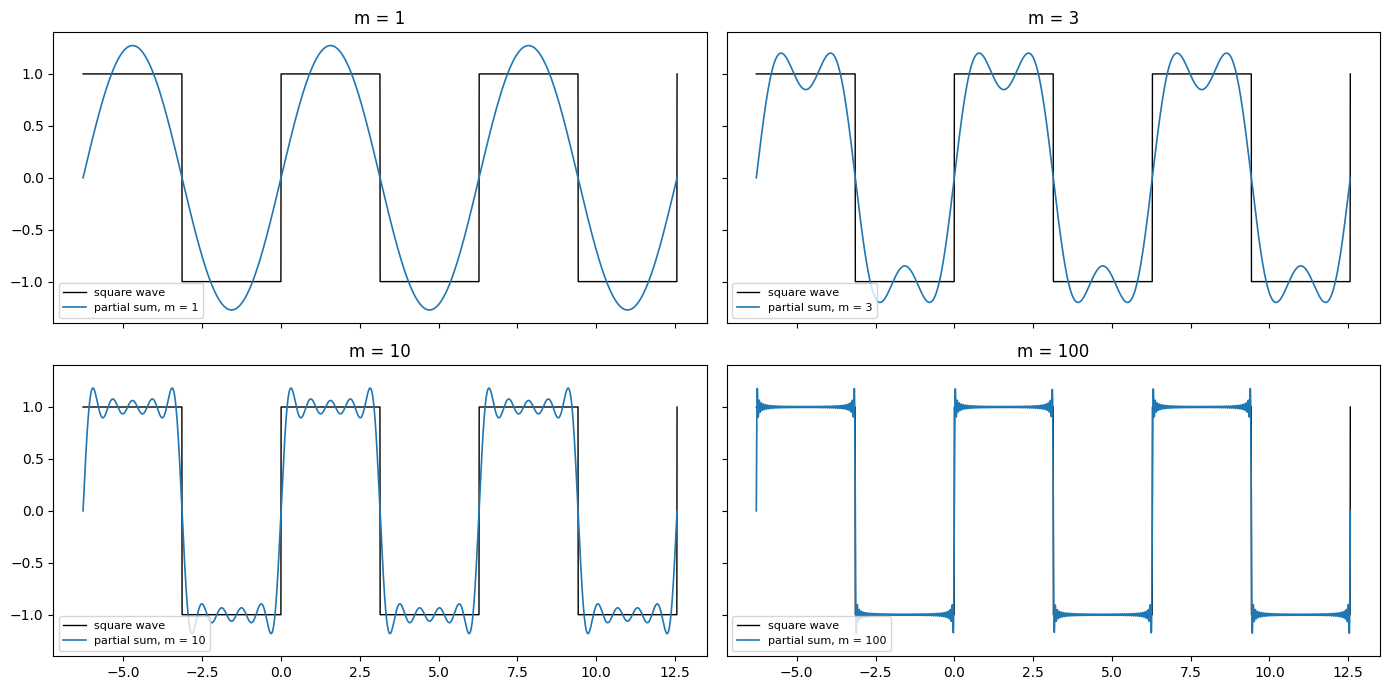

In [2]:
T = 2 * np.pi
t = np.linspace(-T, 2 * T, 3000)
square = np.where(np.mod(t, T) < np.pi, 1.0, -1.0)

def partial_sum(t, m):
    k = np.arange(1, m + 1)
    b = 2 * (1 - (-1.0) ** k) / (np.pi * k)
    return (b[:, None] * np.sin(np.outer(k, t))).sum(axis=0)

fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True, sharey=True)
for ax, m in zip(axes.flat, [1, 3, 10, 100]):
    ax.plot(t, square, color="black", lw=1, label="square wave")
    ax.plot(t, partial_sum(t, m), color="tab:blue", lw=1.2, label=f"partial sum, m = {m}")
    ax.set_title(f"m = {m}")
    ax.legend(loc="lower left", fontsize=8)
fig.tight_layout()
plt.show()

A single sine already captures the rough shape; adding more terms sharpens the edges. Near each jump, however, the partial sums **overshoot** the function, and the overshoot does not disappear as $m$ grows: it just becomes narrower. This is the **Gibbs phenomenon**.

In [3]:
for m in [10, 100, 1000]:
    print(f"m = {m:>4}: maximum of the partial sum = {partial_sum(np.linspace(0, 0.5, 20000), m).max():.4f}")

m =   10: maximum of the partial sum = 1.1823
m =  100: maximum of the partial sum = 1.1790


m = 1000: maximum of the partial sum = 1.1790


The maximum converges to about 1.179, an overshoot of roughly 9% of the jump size (from −1 to +1), no matter how many terms are used. The lesson carries over to data: sharp changes in a signal spread their energy over many frequencies, and a filter that keeps only a few frequencies will smooth those changes out.

## 2. Daily electricity consumption in Switzerland

The dataset contains, for every day of 2022, the average electricity consumed by end users in the Swiss control area per quarter of an hour (kWh).

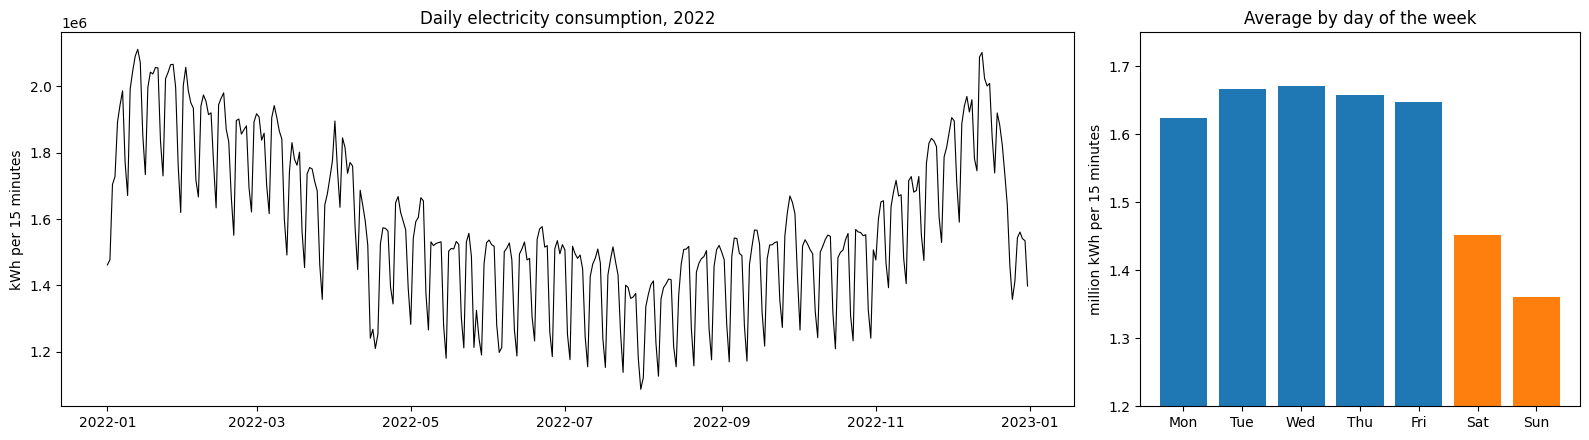

In [4]:
energy = pd.read_csv("data/swiss_electricity_consumption_2022.csv", parse_dates=["date"], index_col="date")["consumption_kwh_per_15min"]
weekday_mean = energy.groupby(energy.index.dayofweek).mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4.5), gridspec_kw={"width_ratios": [2.3, 1]})
ax1.plot(energy, color="black", lw=0.8)
ax1.set(title="Daily electricity consumption, 2022", ylabel="kWh per 15 minutes")
ax2.bar(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"], weekday_mean / 1e6, color=["tab:blue"] * 5 + ["tab:orange"] * 2)
ax2.set(title="Average by day of the week", ylabel="million kWh per 15 minutes", ylim=(1.2, 1.75))
fig.tight_layout()
plt.show()

Two patterns are visible: a **yearly cycle** (high consumption in winter for heating and lighting, low in summer) and a **weekly cycle** (weekends consume about 15% less than working days, because offices and industry are closed). There are also a few isolated dips that we will come back to.

### The amplitude spectrum

For a series $x_0, \dots, x_{n-1}$, the discrete Fourier transform gives one complex coefficient $c_k$ per frequency $k/n$ cycles per day. Frequency $k$ corresponds to a **period of $n/k$ days**, and $|c_k|$ is the amplitude of the sine wave with that period. Since the data are real, it is enough to look at $k = 0, \dots, n/2$ (doubling the amplitudes for $k \ge 1$ to account for the mirror-image negative frequencies).

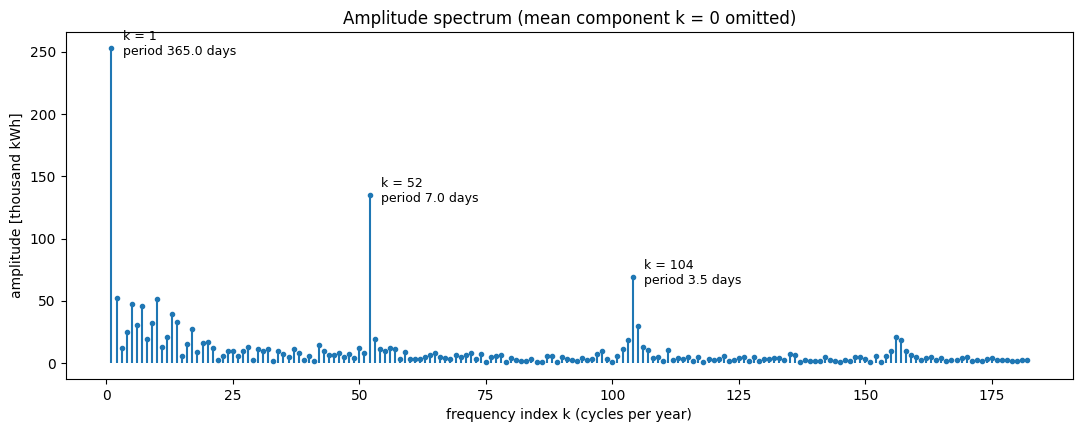

,k,period [days],amplitude
1,1,365.0,253133.0
52,52,7.0,134819.5
104,104,3.5,68790.6
2,2,182.5,52041.5
10,10,36.5,51369.3
5,5,73.0,47285.2
7,7,52.1,45395.7
13,13,28.1,39505.9


In [5]:
x = energy.to_numpy()
n = len(x)
coef = np.fft.rfft(x) / n                       # c_0, c_1, ..., c_{n/2}
amplitude = np.abs(coef) * np.r_[1, 2 * np.ones(len(coef) - 1)]
k = np.arange(len(coef))

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.stem(k[1:], amplitude[1:] / 1e3, basefmt=" ", markerfmt=".")
for kk in [1, 52, 104]:
    ax.annotate(f"k = {kk}\nperiod {n / kk:.1f} days", (kk, amplitude[kk] / 1e3), textcoords="offset points", xytext=(8, -5), fontsize=9)
ax.set(xlabel="frequency index k (cycles per year)", ylabel="amplitude [thousand kWh]", title="Amplitude spectrum (mean component k = 0 omitted)")
plt.show()

top = pd.DataFrame({"k": k, "period [days]": n / np.maximum(k, 1), "amplitude": amplitude}).iloc[1:]
top.sort_values("amplitude", ascending=False).head(8).round(1)

The spectrum is dominated by a few clear peaks:

- **k = 1** (period 365 days): the yearly cycle, the largest by far;
- **k = 52** (period 7 days): the weekly cycle;
- **k = 104** (period 3.5 days): the first **harmonic** of the weekly cycle. The weekly pattern is not a pure sine wave (five similar working days followed by two low days, a shape closer to a square wave), so it needs higher harmonics to be represented, exactly as the square wave of section 1 did. A smaller peak at **k = 156** (period 2.3 days) is the next harmonic;
- small values of $k$ (2, 5, 7, 10, ...): slower variations within the year, such as the different shape of winter and summer.

## 3. Filtering: keeping only the strong frequencies

If the series is mostly made of a few strong cycles plus noise, we can **filter** it: set all coefficients with an amplitude below a threshold to zero and transform back with the inverse FFT.

In [6]:
def reconstruct(threshold):
    kept = np.where(amplitude >= threshold, coef, 0)
    return pd.Series(np.fft.irfft(kept * n, n), index=energy.index), int((amplitude >= threshold).sum())

rows = []
for threshold in [100e3, 50e3, 30e3, 20e3, 10e3]:
    smooth, kept = reconstruct(threshold)
    rows.append({"threshold": threshold, "coefficients kept": kept, "R2": 1 - np.sum((x - smooth) ** 2) / np.sum((x - x.mean()) ** 2)})
pd.DataFrame(rows).round(3)

,threshold,coefficients kept,R2
0,100000.0,3,0.734
1,50000.0,6,0.824
2,30000.0,12,0.903
3,20000.0,17,0.931
4,10000.0,40,0.970


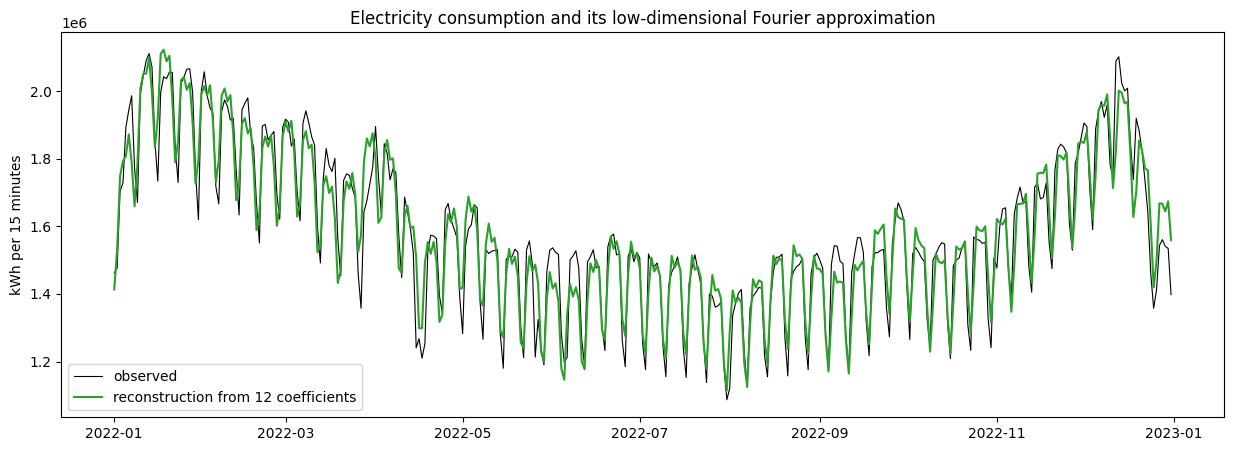

In [7]:
smooth, kept = reconstruct(30e3)
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(energy, color="black", lw=0.8, label="observed")
ax.plot(smooth, color="tab:green", lw=1.5, label=f"reconstruction from {kept} coefficients")
ax.set(title="Electricity consumption and its low-dimensional Fourier approximation", ylabel="kWh per 15 minutes")
ax.legend()
plt.show()

With only a dozen coefficients (out of 183), the reconstruction explains about 90% of the variance: it reproduces the yearly cycle, the weekly rhythm and the slower seasonal changes. The filtered signal is a compact description of the "normal" behaviour of consumption.

### What the filter leaves out

The days where the observed value differs most from the reconstruction are, by construction, the days that do not follow the usual pattern:

In [8]:
residual = energy - smooth
largest = residual.sort_values().head(8)
pd.DataFrame({"weekday": largest.index.day_name(), "residual [thousand kWh]": (largest / 1e3).round(0)})

,weekday,residual [thousand kWh]
date,,
2022-05-26,Thursday,-274.0
2022-04-15,Friday,-265.0
2022-04-18,Monday,-239.0
2022-03-27,Sunday,-215.0
2022-01-16,Sunday,-187.0
2022-03-29,Tuesday,-185.0
2022-01-30,Sunday,-178.0
2022-08-01,Monday,-169.0


Half of the largest negative residuals fall on **public holidays**: Ascension Day (26 May), Good Friday (15 April), Easter Monday (18 April) and the Swiss National Day (1 August). Shops, offices and factories are closed, so consumption drops to a weekend level on a weekday, something a sum of regular cycles cannot anticipate. Three more are Sundays that were even quieter than the average weekend, which the smooth weekly component cannot fully reproduce (the same smoothing effect as the Gibbs phenomenon at the edges of the square wave).

This is a practical use of spectral filtering: once the regular cycles are removed, the residual highlights **calendar effects and anomalies**. A forecasting model for electricity demand would add holiday indicators to capture exactly these days.

## Summary

- Periodic functions are sums of sines and cosines. Sharp edges need many terms, and truncating the series produces the **Gibbs overshoot**.
- The **amplitude spectrum** of a time series shows which periods carry its variation: here the yearly cycle, the weekly cycle and its harmonics.
- Non-sinusoidal cycles, like a five-day working week, show up as a fundamental frequency plus **harmonics**.
- **Thresholding** the Fourier coefficients gives a compact, smooth reconstruction of the regular pattern, and its residuals point to irregular events such as public holidays.